# Model 3: Damage Level Classification

**Goal:** Given a cropped image of a building, classify damage severity: None, Minor, Major, Destroyed.

Since xBD assesses damage on a *per-building* basis, the data loading step involves parsing the JSON polygons, isolating the building from the high-res PNG, and making patches.

In [22]:
import os
import json
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

## 1. Class and Loss Definition
Building Damage is an ordinal classification problem (No damage < Minor < Major < Destroyed). We use Categorical Crossentropy, but weighted loss or Focal Loss is better for imbalanced disaster datasets.

In [23]:
# Class Mapping
damage_map = {
    "no-damage": 0,
    "minor-damage": 1,
    "major-damage": 2,
    "destroyed": 3
}
num_classes = 4

# Advanced Model replacing basic CNN
patch_input = layers.Input(shape=(128, 128, 3)) # Patches of buildings

# Preprocessing layers attached to network directly
x = layers.Rescaling(1./255)(patch_input)
x = layers.RandomRotation(0.1)(x)
x = layers.RandomZoom(0.1)(x)

# Feature Extractor
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs=patch_input, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',  # To improve further, implement Focal Loss for Imbalanced learning
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,092 (16.36 MB)

 Trainable params: 4,288,644 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

## 2. Fast Crop Generator & Training
We parse polygons dynamically to crop building bounding boxes out on the fly.

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Class Mapping
damage_map = {
    "no-damage": 0,
    "minor-damage": 1,
    "major-damage": 2,
    "destroyed": 3
}
num_classes = 4

# --- CUSTOM FOCAL LOSS ---
def categorical_focal_loss(gamma=2.0):
    def focal_loss(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -tf.cast(y_true, tf.float32) * tf.math.log(y_pred)
        # Down-weight easy examples
        weight = tf.math.pow(1. - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=-1)
    return focal_loss

# Advanced Model replacing basic CNN
patch_input = layers.Input(shape=(128, 128, 3))

# Preprocessing layers
x = layers.Rescaling(1./255)(patch_input)
x = layers.RandomRotation(0.1)(x)
x = layers.RandomZoom(0.1)(x)

# Feature Extractor
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D()(x)

x = layers.Flatten()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs=patch_input, outputs=outputs)

# Compile using Focal Loss and a slightly lower learning rate for stability
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
    loss=categorical_focal_loss(gamma=2.0),
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289,092 (16.36 MB)

 Trainable params: 4,288,644 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [25]:
print("Training Damage Classifier with Focal Loss...")

# No class_weight dictionary needed anymore!
history = model.fit(
    train_ds, 
    epochs=3, 
    steps_per_epoch=150
)

model.save("damage_classifier.h5")
print("Saved Model")

Training Damage Classifier with Focal Loss...
Epoch 1/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 74s 474ms/step - accuracy: 0.6350 - loss: 5.5047
Epoch 2/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 70s 466ms/step - accuracy: 0.7004 - loss: 4.8254
Epoch 3/3
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 475ms/step - accuracy: 0.7835 - loss: 3.4889


Saved Model


## 3. Test Set Evaluation
Let's extract building patches from unseen test images and evaluate the Damage Classifier's accuracy.

In [26]:
test_paths = glob.glob(os.path.join("../test/images", "*post_disaster.png"))
# Same fast evaluation subset
test_ds = tf.data.Dataset.from_tensor_slices(test_paths[:100])
test_ds = test_ds.flat_map(py_func_wrapper)
test_ds = test_ds.map(lambda x,y: (tf.ensure_shape(x, [128, 128, 3]), tf.one_hot(tf.ensure_shape(y, []), 4))).batch(32).prefetch(tf.data.AUTOTUNE)

print("Evaluating Damage Classifier on Test Set...")
results = model.evaluate(test_ds)
print(f"Test Loss: {results[0]:.4f}, Test Accuracy: {results[1]:.4f}")


Evaluating Damage Classifier on Test Set...
217/217 ━━━━━━━━━━━━━━━━━━━━ 26s 119ms/step - accuracy: 0.8091 - loss: 3.0731
Test Loss: 3.0731, Test Accuracy: 0.8091


/opt/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


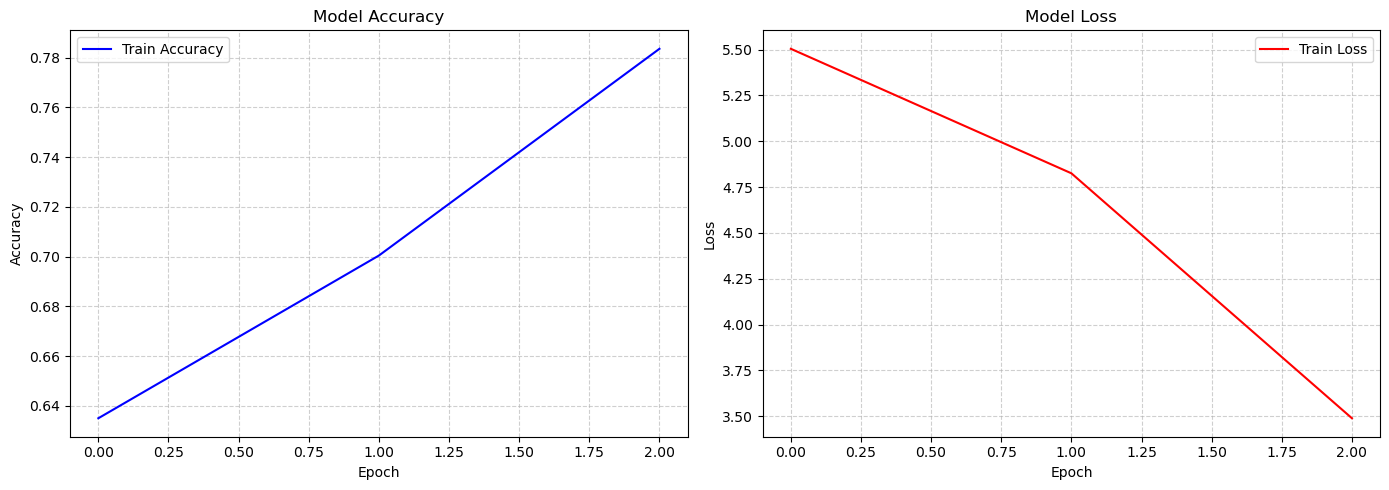

In [27]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    # ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange') # Uncomment if using validation split
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Plot Loss
    ax2.plot(history.history['loss'], label='Train Loss', color='red')
    # ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange') # Uncomment if using validation split
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

# Assuming 'history' is still in memory from the training cell
try:
    plot_history(history)
except NameError:
    print("History object not found. Ensure you run the training cell before this one.")

Generating predictions for the Confusion Matrix...


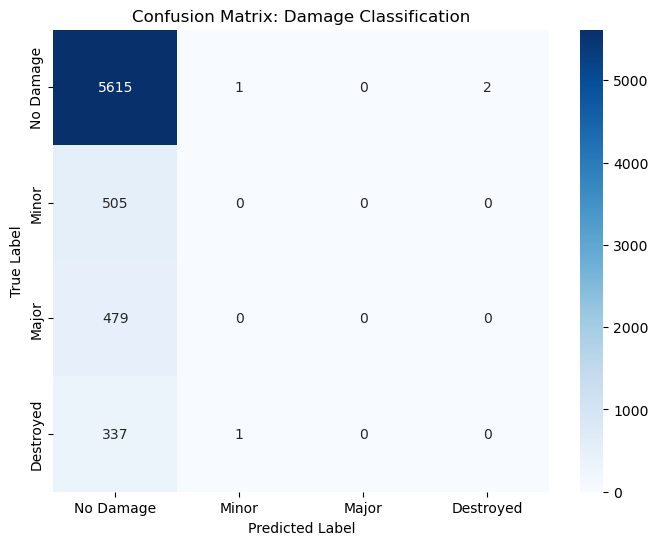


Classification Report:

              precision    recall  f1-score   support

   No Damage       0.81      1.00      0.89      5618
       Minor       0.00      0.00      0.00       505
       Major       0.00      0.00      0.00       479
   Destroyed       0.00      0.00      0.00       338

    accuracy                           0.81      6940
   macro avg       0.20      0.25      0.22      6940
weighted avg       0.66      0.81      0.72      6940



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

print("Generating predictions for the Confusion Matrix...")

y_true = []
y_pred_classes = []

# Iterate through the test dataset to get predictions and true labels
for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_pred_classes.extend(np.argmax(preds, axis=1))
    y_true.extend(np.argmax(y_batch.numpy(), axis=1))

class_names = ["No Damage", "Minor", "Major", "Destroyed"]

# Generate Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Damage Classification')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Print Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

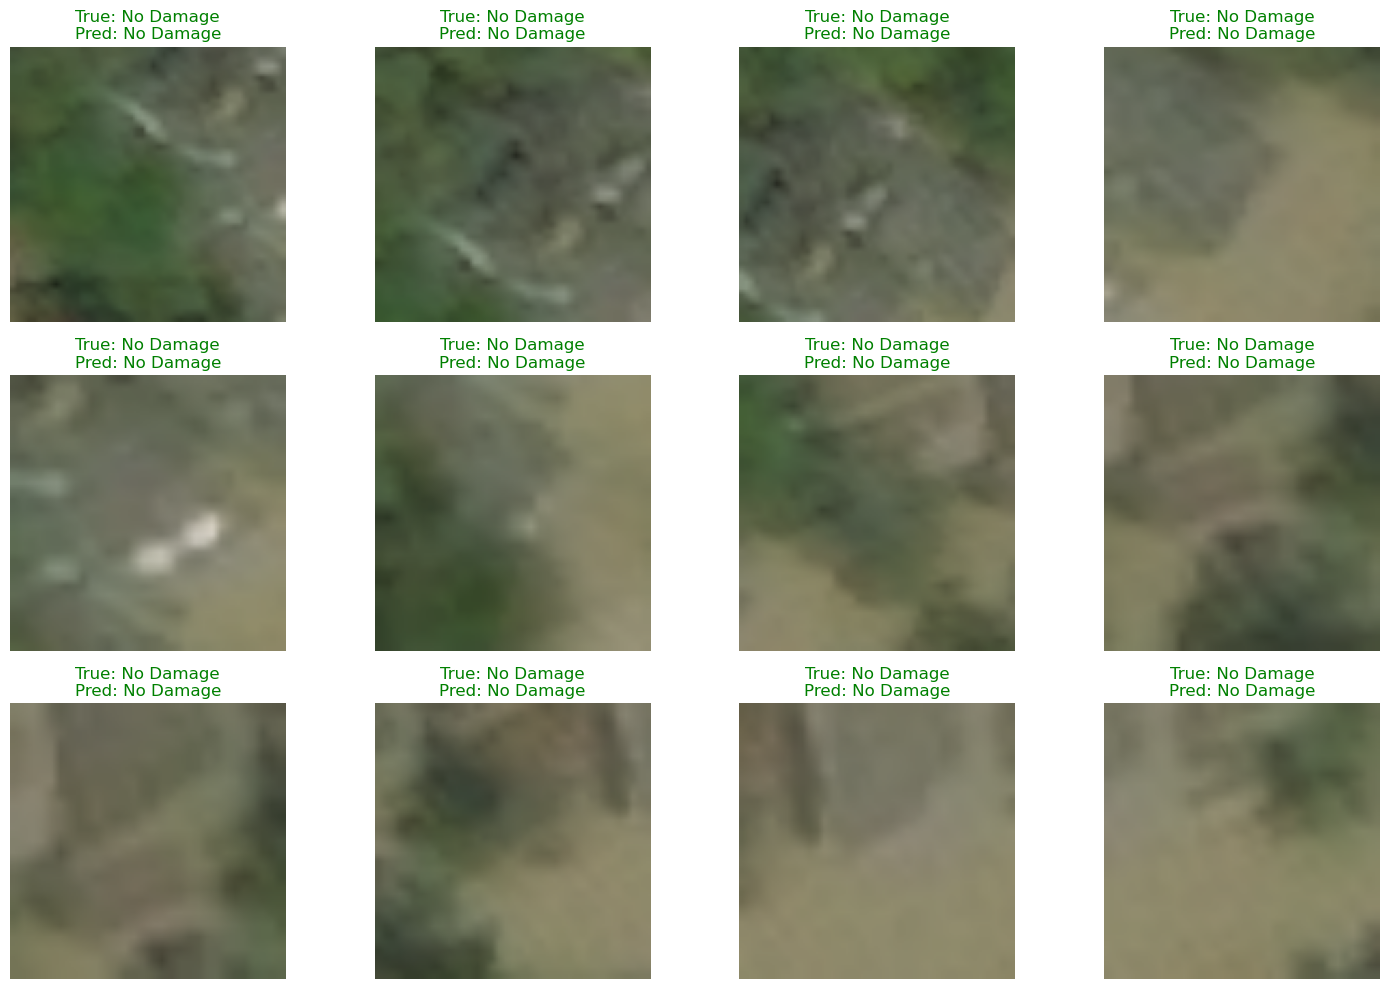

In [31]:
plt.figure(figsize=(15, 10))

# Take a single batch from the test dataset
for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)
    
    # Plot up to 12 images from the batch
    num_images = min(12, len(images))
    for i in range(num_images):
        ax = plt.subplot(3, 4, i + 1)
        
        # Images were left in 0-255 range for cv2, cast to uint8 for matplotlib
        img = images[i].numpy().astype("uint8")
        
        true_label = class_names[np.argmax(labels[i].numpy())]
        pred_label = class_names[np.argmax(preds[i])]
        
        plt.imshow(img)
        
        # Color title green if correct, red if incorrect
        title_color = 'green' if true_label == pred_label else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=title_color)
        plt.axis("off")

plt.tight_layout()
plt.show()